Cadastro: 10000 (100%)
Ativação: 8038 (80.38%)
Engajamento: 2069 (20.69%)
Conversão: 100 (1.00%)


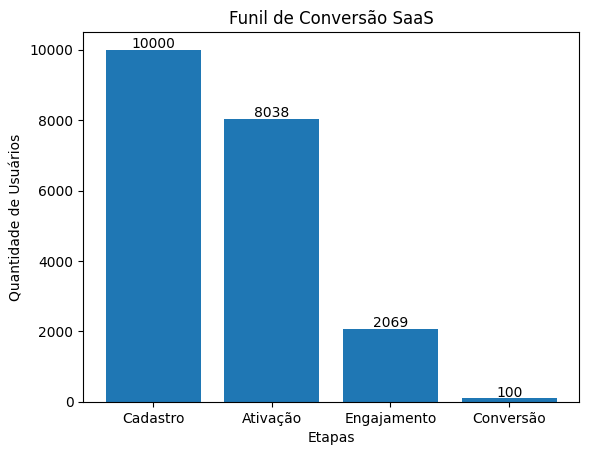

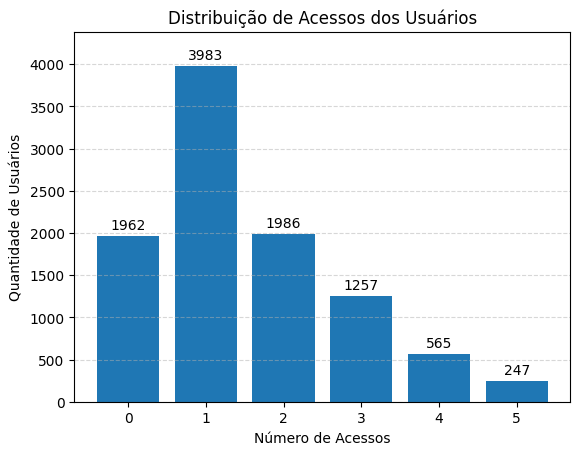

engajado  plano
0         free     1.000000
1         free     0.951667
          pago     0.048333
Name: proportion, dtype: float64


In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

total_users = 10000

df = pd.DataFrame({
    "user_id": range(1, total_users + 1)
})

# Ativação (80%)
df["usou_produto"] = np.random.choice([1, 0], size=total_users, p=[0.8, 0.2])

# Número de acessos
df["numero_acessos"] = 0

# Para quem usou o produto
df.loc[df["usou_produto"] == 1, "numero_acessos"] = np.random.choice(
    [1, 2, 3, 4, 5],
    size=df["usou_produto"].sum(),
    p=[0.5, 0.25, 0.15, 0.07, 0.03]  # maioria com poucos acessos
)

# Engajamento (>=3 acessos)
df["engajado"] = (df["numero_acessos"] >= 3).astype(int)

# Conversão (1% do total, mas só entre engajados)
df["plano"] = "free"

pagantes_index = df[df["engajado"] == 1].sample(n=100, random_state=42).index
df.loc[pagantes_index, "plano"] = "pago"

df.head()

total = len(df)
ativados = df["usou_produto"].sum()
engajados = df["engajado"].sum()
pagantes = (df["plano"] == "pago").sum()

print(f"Cadastro: {total} ({100:.0f}%)")
print(f"Ativação: {ativados} ({ativados/total:.2%})")
print(f"Engajamento: {engajados} ({engajados/total:.2%})")
print(f"Conversão: {pagantes} ({pagantes/total:.2%})")

import os

os.makedirs("imagens", exist_ok=True)

import matplotlib.pyplot as plt

etapas = ["Cadastro", "Ativação", "Engajamento", "Conversão"]
valores = [total, ativados, engajados, pagantes]

plt.figure()
plt.bar(etapas, valores)

for i, v in enumerate(valores):
    plt.text(i, v + 50, str(v), ha='center')

plt.title("Funil de Conversão SaaS")
plt.xlabel("Etapas")
plt.ylabel("Quantidade de Usuários")
plt.savefig("imagens/funil.png")
plt.show()

acessos_count = df["numero_acessos"].value_counts().sort_index()

plt.figure()
plt.bar(acessos_count.index, acessos_count.values)

for i, v in enumerate(acessos_count.values):
    plt.text(acessos_count.index[i], v + (max(acessos_count.values) * 0.02), str(v), ha='center')

plt.title("Distribuição de Acessos dos Usuários")
plt.xlabel("Número de Acessos")
plt.ylabel("Quantidade de Usuários")
plt.xticks(acessos_count.index)

plt.ylim(0, max(acessos_count.values) * 1.1)  # dá espaço no topo
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("imagens/acessos.png")
plt.show()

df.groupby("engajado")["plano"].value_counts(normalize=True)
df.groupby("numero_acessos")["plano"].apply(lambda x: (x == "pago").mean())
df[df["plano"] == "pago"]["numero_acessos"].describe()
print(df.groupby("engajado")["plano"].value_counts(normalize=True))